In [8]:
import math

from scipy.io import arff
from operator import index

import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors, KernelDensity
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import scipy.stats
from scipy.stats import expon, skew, norm,gamma, anderson,goodness_of_fit, monte_carlo_test, probplot, skewnorm
from scipy import integrate
from sklearn.metrics import auc
import seaborn as sns
import math

from statsmodels.sandbox.distributions.gof_new import kstest

plt.rcParams['figure.figsize'] = [15, 7]
import warnings
from scipy import stats

warnings.filterwarnings('ignore')

In [9]:
def setupDf(fileName):
    arff_file = arff.loadarff(f'./{fileName}') # import the attribute-relation file format
    df4 = pd.DataFrame(arff_file[0])
    if fileName[0] == 'c': # checks if the file is a synthetic dataset
        X = df4.iloc[:,:2].values
        y = df4.iloc[:,2].values
        le = LabelEncoder()
        y = le.fit_transform(y)
    else:
        #drop the outlier and id columns for the independent variables.
        X = df4.drop(columns=['outlier','id']).values
        #get outlier values
        y = df4['outlier'].values
        le = LabelEncoder()
        #encoded the variables as 0=non-outlier, 1=outlier
        y = le.fit_transform(y)
    return X, y

def main(X, y, n):
    #find the nearestNeighbors
    nn = NearestNeighbors(n_neighbors=n,p=1)
    nn.fit(X, y)
    #return the dist of each and the nearest neighbors
    dist, knn = nn.kneighbors(X)  # returns N index neighbors including self
    return knn, dist

def generateArr(newDist, distanceMetric='max'):
    arr = []
    #returns an array based on the median and max values
    for x in newDist:  # finds the distance away from that point (index 0)
        if distanceMetric == 'median':
            arr += [np.median(x)]
        elif distanceMetric == 'sum':  # min + median + max
            arr += [x[1] + np.max(x) + np.median(x)]
        elif distanceMetric == 'max':
            arr += [np.max(x)]
        elif distanceMetric == 'minMax':
            arr += [np.max(x) + x[1]]
        elif distanceMetric == 'medMax':
            arr += [np.median(x) + np.max(x)]
        elif distanceMetric == 'min':
            arr += [x[1]]

    return arr

def outputResults(X,y,lowerRange=2,upperRange=70):
    tots = []
    posNeg4 = []
    for v in range(lowerRange,upperRange):
        knn, distReturn = main(X, y, v) # returns index and distance of points
        distReturn = np.array(distReturn)
        arr = generateArr(distReturn, distanceMetric="medMax") # return arr of max values
        params = stats.invgamma.fit(arr) # fit params for gamma distribution
        posNeg4 = []
        spaceStep4 = np.linspace(0,.99,30) # threshold from 0 to .99, 30 samples
        for e in spaceStep4:
            newArr = arr > stats.invgamma.ppf(e,params[0],loc=params[1], scale=params[2]) # if arr value is outside threshold add to new array
            posNeg4.append([((y[newArr] == 1).sum() / (y == 1).sum()), (y[newArr] != 1).sum()/ ((y != 1).sum())]) # True positive rate, false positive rate

        posNeg4 = np.array(posNeg4)
        arrtest1, arrtest2 = np.split(posNeg4, 2,axis=1) # split the array
        tots += [auc(arrtest2, arrtest1)] # return the area under the curve

    return tots

def printResults(arr):
    arr = np.nan_to_num(arr)
    arr = list(arr)
    print(max(arr),arr.index(max(arr))+2,arr) #print the max values, the k value, and the array

def qqPlots(X,y,kValue,name):
    knn, distReturn = main(X, y, kValue)
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, distanceMetric="max")
    params = stats.invgamma.fit(arr)
    print(f"a: {params[0]} Loc: {params[1]}, Scale: {params[2]}")
    print(skew(arr),np.var(arr))
    fig, ax = plt.subplots(2,1)
    results = probplot(arr,dist=stats.gamma, plot=ax[0],sparams=(params[0],params[1],params[2]),rvalue=True)
    fig.suptitle(name)
    dista = plt.hist(arr,bins=int(np.sqrt(len(arr))),density=True)
    sns.kdeplot(arr,bw=.3)
    plt.xlabel("Maximum Manhattan Distance")
    plt.ylabel("Density")
    plt.show()

0.7557098519815375 52 [0.7430168709215345, 0.750278529364953, 0.749920420181442, 0.7447576794524908, 0.7478911348082126, 0.7472843386917079, 0.7485377208339965, 0.7501293172051569, 0.7497214706350469, 0.7503382142288716, 0.7491644119051408, 0.7500198949546395, 0.7507361133216616, 0.7515915963711602, 0.7528350310361293, 0.7545459971351265, 0.7525366067165367, 0.7519497055546713, 0.7498308928855641, 0.7521884450103453, 0.7518900206907528, 0.7514622791660035, 0.751482174120643, 0.7518999681680725, 0.7524570268979787, 0.7528549259907688, 0.7527156613082923, 0.7536905140856279, 0.754685261817603, 0.7550831609103931, 0.7554213751392646, 0.7552124781155499, 0.7543470475887315, 0.7550433710011141, 0.7550135285691548, 0.7543072576794524, 0.7549339487505968, 0.7535810918351107, 0.7540585707464587, 0.7534716695845933, 0.7531036129237626, 0.7539093585866624, 0.7538695686773833, 0.7544664173165685, 0.7541779404742958, 0.754048623269139, 0.7527057138309725, 0.7527653986948909, 0.754207782906255, 0.7

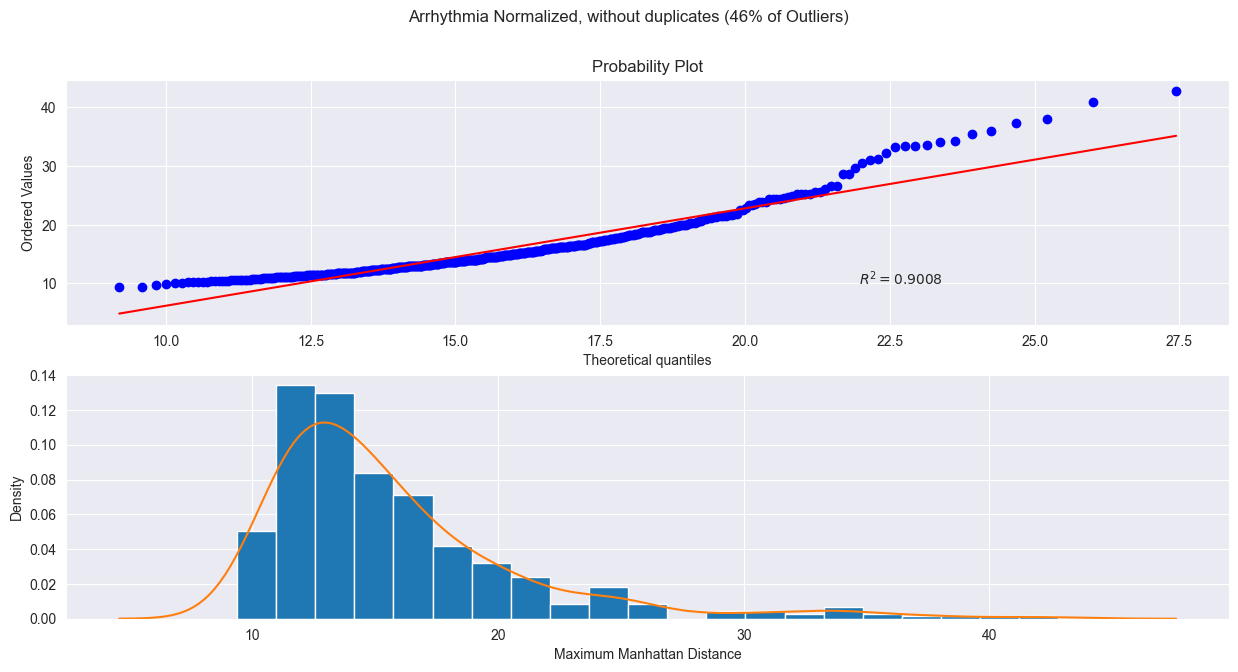

In [10]:
X, y = setupDf("real/Arrhythmia_withoutdupl_norm_46.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,41,"Arrhythmia Normalized, without duplicates (46% of Outliers)")

0.7138605442176871 6 [0.607780612244898, 0.6525651927437641, 0.6947987528344671, 0.6967120181405896, 0.7138605442176871, 0.7057114512471655, 0.6963577097505668, 0.6844529478458049, 0.6743197278911565, 0.6728316326530612, 0.6647534013605442, 0.6470379818594104, 0.6424319727891156, 0.6274092970521542, 0.6166383219954648, 0.6357001133786848, 0.6163548752834468, 0.6006235827664399, 0.59984410430839, 0.591624149659864, 0.591765873015873, 0.5876558956916099, 0.5882227891156462, 0.5823412698412698, 0.5807114512471655, 0.5751133786848073, 0.5706490929705216, 0.5824121315192743, 0.569515306122449, 0.5707908163265306, 0.5674603174603174, 0.5638463718820862, 0.5643424036281179, 0.5622165532879819, 0.5634920634920635, 0.562358276643991, 0.5604450113378685, 0.5586026077097506, 0.5581065759637188, 0.5561224489795918, 0.55640589569161, 0.5552721088435374, 0.5540674603174605, 0.5458475056689343, 0.5498866213151927, 0.548469387755102, 0.5478316326530612, 0.5439342403628118, 0.5422335600907029, 0.537627

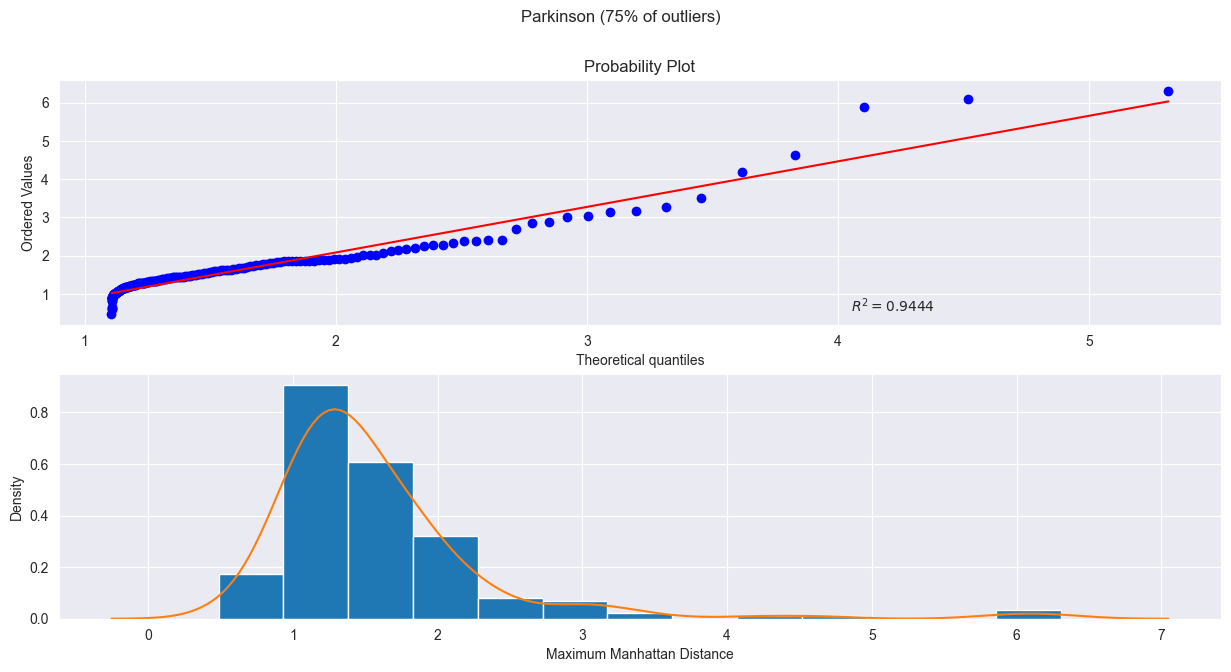

In [11]:
X, y = setupDf("real/Parkinson_withoutdupl_norm_75.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,6,"Parkinson (75% of outliers)")

0.8189615384615385 9 [0.3143461538461539, 0.38784615384615384, 0.5414615384615384, 0.7214999999999999, 0.747076923076923, 0.7620769230769231, 0.8071538461538462, 0.8189615384615385, 0.8182692307692309, 0.8167307692307691, 0.8011153846153846, 0.8008846153846153, 0.7910384615384615, 0.7888076923076922, 0.7863461538461538, 0.7767692307692307, 0.7794999999999999, 0.7770769230769231, 0.7755, 0.7758461538461537, 0.7711923076923077, 0.7623076923076924, 0.7628076923076923, 0.7617307692307691, 0.7611923076923077, 0.7577692307692309, 0.7468461538461539, 0.7544999999999998, 0.7564615384615384, 0.7550769230769231, 0.7543461538461539, 0.7533461538461539, 0.7475384615384615, 0.7407307692307693, 0.7403846153846154, 0.7407692307692308, 0.7430769230769231, 0.7396538461538462, 0.7396538461538461, 0.7389230769230769, 0.7380384615384618, 0.7411153846153847, 0.731923076923077, 0.7319615384615386, 0.7283076923076923, 0.7272692307692308, 0.7241923076923078, 0.7220769230769231, 0.7227307692307693, 0.719000000

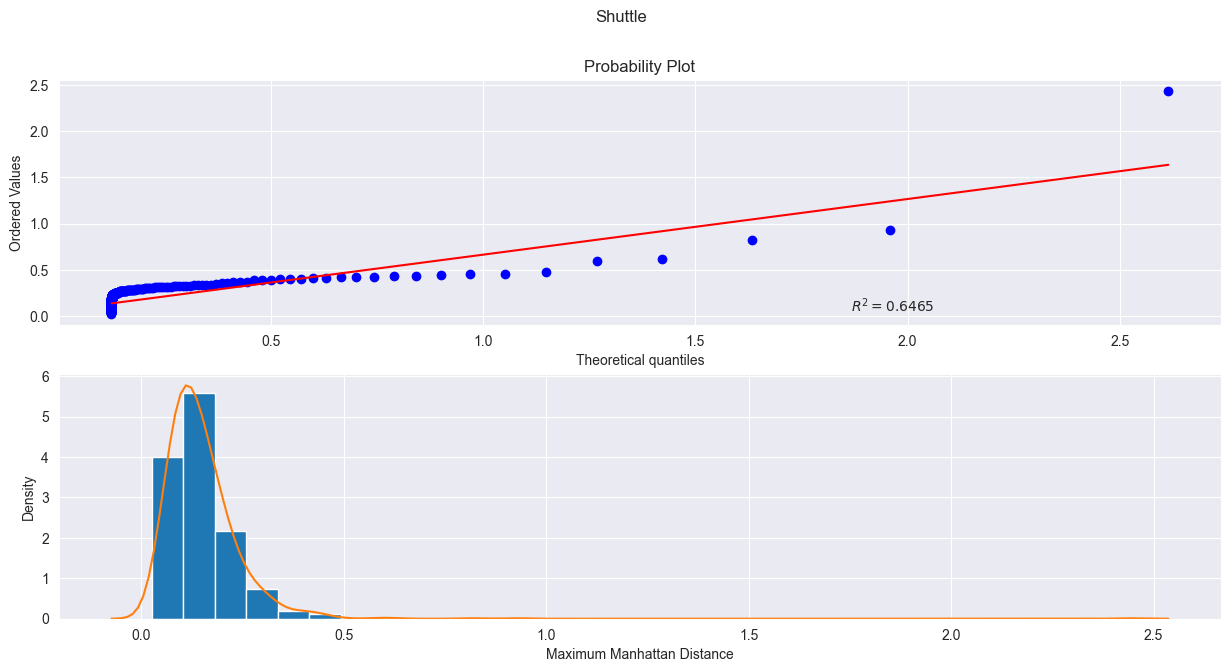

In [12]:
X, y = setupDf("real/Shuttle_withoutdupl_norm_v10.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,5,"Shuttle")

0.9854460093896715 10 [0.411737089201878, 0.6206572769953049, 0.7300469483568075, 0.8284037558685446, 0.8892018779342723, 0.9413145539906103, 0.9551643192488262, 0.976056338028169, 0.9854460093896715, 0.8805164319248825, 0.9366197183098591, 0.9368544600938968, 0.9553990610328639, 0.9553990610328639, 0.9741784037558686, 0.974413145539906, 0.9838028169014084, 0.9838028169014084, 0.9835680751173709, 0.9368544600938966, 0.9415492957746477, 0.9462441314553992, 0.946244131455399, 0.9605633802816901, 0.9699530516431926, 0.974413145539906, 0.9746478873239438, 0.9793427230046947, 0.9793427230046949, 0.9795774647887325, 0.9795774647887325, 0.984037558685446, 0.9842723004694836, 0.984037558685446, 0.9089201877934272, 0.9089201877934272, 0.9274647887323944, 0.9321596244131455, 0.9370892018779343, 0.9370892018779343, 0.9417840375586856, 0.9464788732394365, 0.9464788732394366, 0.9469483568075117, 0.9469483568075115, 0.9469483568075117, 0.956338028169014, 0.956338028169014, 0.9657276995305163, 0.9657

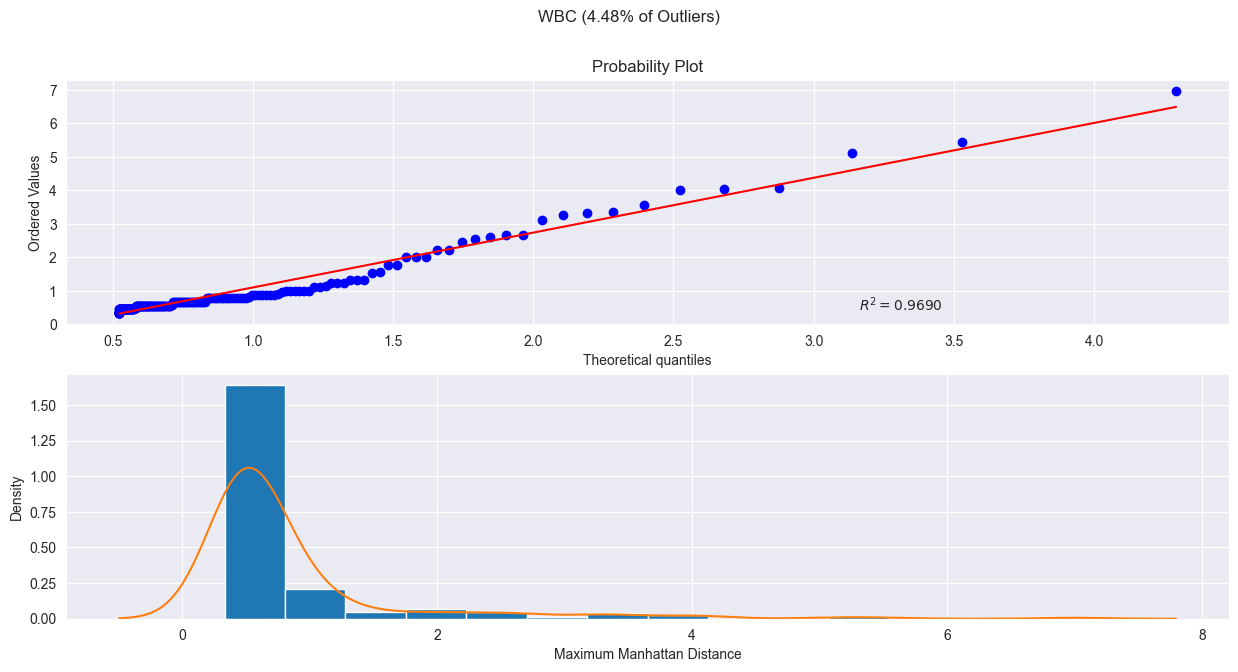

In [13]:
X, y = setupDf("real/WBC_withoutdupl_norm_v10.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,40,"WBC (4.48% of Outliers)")

0.6489228914890569 50 [0.40903630382008577, 0.44767242971630195, 0.48226321423994095, 0.5042893034582068, 0.5232769986278752, 0.5429924570834057, 0.5566771869180723, 0.5631666255154893, 0.5759057813948932, 0.5867648624859583, 0.5938662677829631, 0.5997797862274862, 0.6052215189873418, 0.6094983357332951, 0.6121060560083231, 0.6143608499634352, 0.6197238928762598, 0.624495230547116, 0.6272324121123936, 0.6298365984122556, 0.6309039767115747, 0.6320288410069286, 0.6332834021908762, 0.6347169003173981, 0.6354075568640164, 0.6372360356149306, 0.6368324556509677, 0.6372770297268568, 0.6387609458990811, 0.6394761046735172, 0.6399769867537187, 0.639891817952217, 0.6408980584811634, 0.6419558950475345, 0.6428469279860677, 0.6431585067965411, 0.6446992021697666, 0.645716398021728, 0.646021380078558, 0.6463975128353977, 0.6462712321227976, 0.6461877125097067, 0.646367238448142, 0.646279006868163, 0.6468250060313175, 0.6471989006038856, 0.6486080143017621, 0.6488273563604015, 0.6489228914890569, 

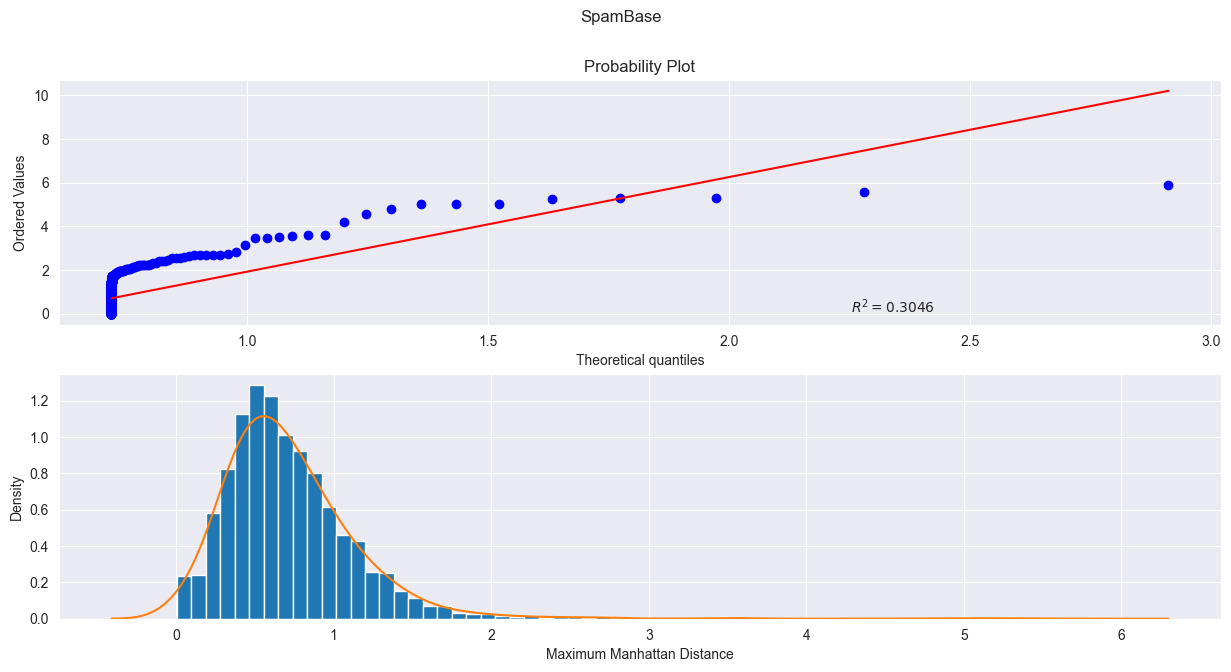

In [14]:
X, y = setupDf("real/SpamBase_withoutdupl_norm_40.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,49,"SpamBase")

0.5304353952374241 12 [0.44589263068902363, 0.4763280259264478, 0.49577286177257995, 0.5100746794420178, 0.5135972946315345, 0.5201493588840355, 0.5191630266309708, 0.5185289558968578, 0.5212061434408904, 0.5256446385796815, 0.5304353952374241, 0.52536282936452, 0.5267718754403269, 0.5172608144286317, 0.5182471466816965, 0.5194448358461321, 0.5212061434408904, 0.5265605185289558, 0.5222629279977454, 0.5205720727067774, 0.5290263491616175, 0.5220515710863745, 0.5228969987318584, 0.5212765957446808, 0.5248696632379879, 0.5205016204029871, 0.5178948851627447, 0.5222629279977454, 0.5199380019726645, 0.5164153867831477, 0.5190925743271804, 0.518176694377906, 0.5181766943779061, 0.5167676483020994, 0.5185289558968577, 0.5181766943779061, 0.5150063407073412, 0.5189516697195997, 0.5158517683528251, 0.5200084542764547, 0.5126109623784697, 0.515429054530083, 0.5167676483020993, 0.5157813160490347, 0.514583626884599, 0.5110610116950823, 0.511835987036776, 0.5126109623784697, 0.5121882485557276, 0

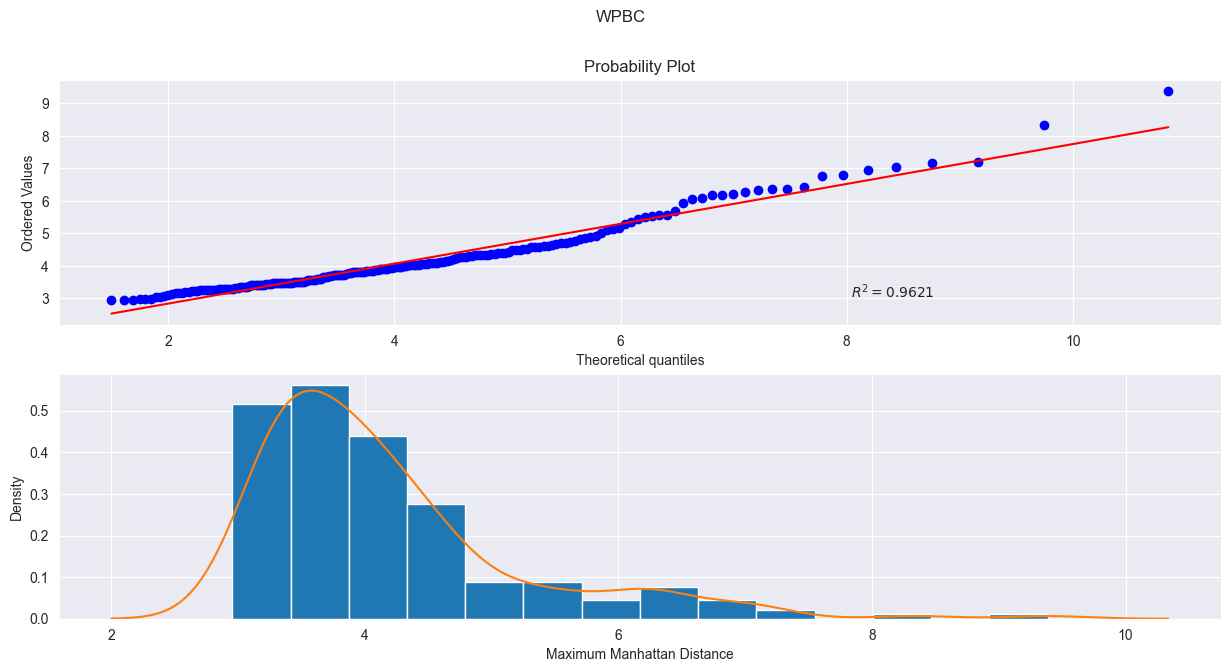

In [15]:
X, y = setupDf("real/WPBC_withoutdupl_norm.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,26,"WPBC")

0.6734166666666666 68 [0.5993055555555555, 0.6181944444444444, 0.6149444444444445, 0.6181111111111111, 0.6198888888888887, 0.6220277777777777, 0.6240833333333333, 0.6266388888888889, 0.6264722222222222, 0.6283611111111111, 0.6295833333333333, 0.6360555555555555, 0.634611111111111, 0.6414999999999998, 0.6422777777777777, 0.6463888888888889, 0.6466666666666666, 0.651111111111111, 0.6478333333333333, 0.6499166666666667, 0.6497222222222221, 0.6492499999999999, 0.6457499999999999, 0.6474444444444445, 0.6524166666666666, 0.6534166666666668, 0.6536111111111111, 0.6563888888888888, 0.6583333333333332, 0.6573611111111111, 0.657611111111111, 0.6564999999999999, 0.6560277777777777, 0.6586111111111111, 0.6571388888888888, 0.655861111111111, 0.6542222222222221, 0.6570277777777777, 0.6557777777777777, 0.6545555555555554, 0.6578611111111111, 0.6580277777777777, 0.6593055555555556, 0.6607499999999998, 0.6603888888888888, 0.6608888888888889, 0.6629166666666667, 0.6605000000000001, 0.6676944444444444, 0

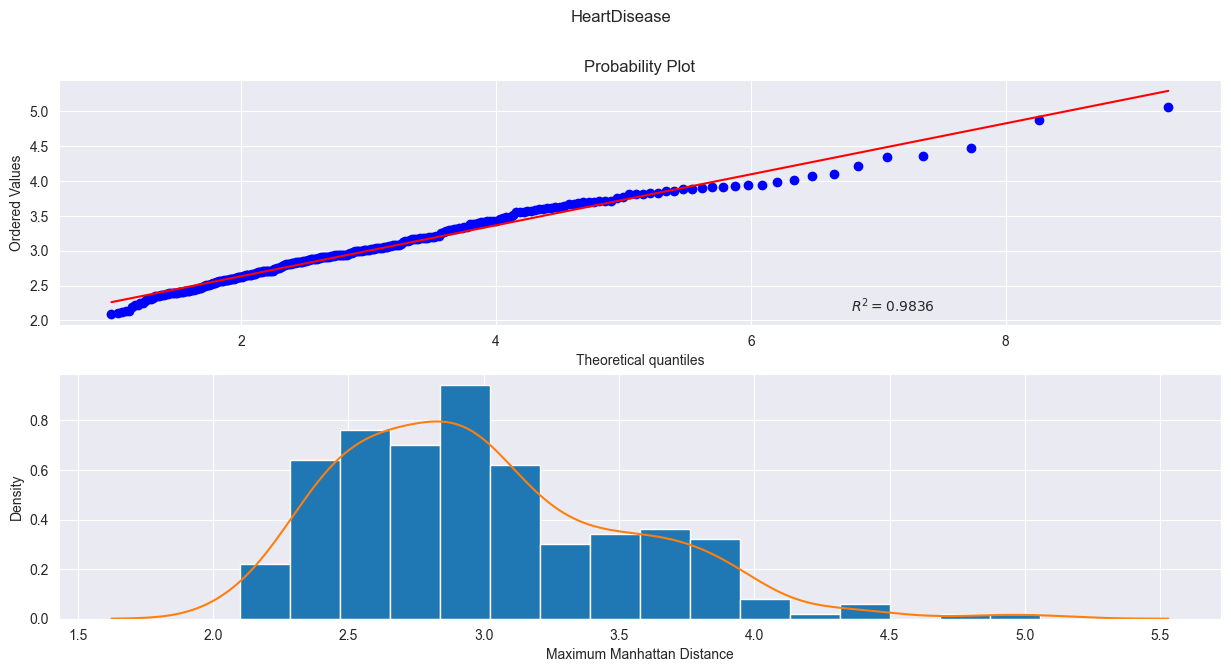

In [16]:
X, y = setupDf("real/HeartDisease_withoutdupl_norm_44.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,66,"HeartDisease")

posx and posy should be finite values


0.8712737127371273 2 [0.8712737127371273, 0.8490514905149051, 0.8558265582655827, 0.8482384823848238, 0.8582655826558266, 0.8615176151761518, 0.8634146341463415, 0.8582655826558265, 0.8642276422764228, 0.8655826558265582, 0.8585365853658536, 0.859620596205962, 0.8634146341463415, 0.8647696476964769, 0.8644986449864497, 0.8658536585365854, 0.8661246612466125, 0.8653116531165311, 0.8647696476964769, 0.8655826558265582, 0.8669376693766938, 0.8582655826558265, 0.8528455284552845, 0.8501355013550135, 0.8441734417344173, 0.8401084010840107, 0.8349593495934958, 0.8333333333333331, 0.8325203252032521, 0.824119241192412, 0.8265582655826559, 0.8292682926829269, 0.8252032520325203, 0.8227642276422764, 0.8214092140921408, 0.8130081300813008, 0.8146341463414634, 0.8132791327913279, 0.8059620596205961, 0.8016260162601626, 0.8065040650406505, 0.8043360433604337, 0.797289972899729, 0.7897018970189702, 0.7902439024390243, 0.7875338753387533, 0.7853658536585366, 0.7845528455284552, 0.7875338753387533, 0

posx and posy should be finite values


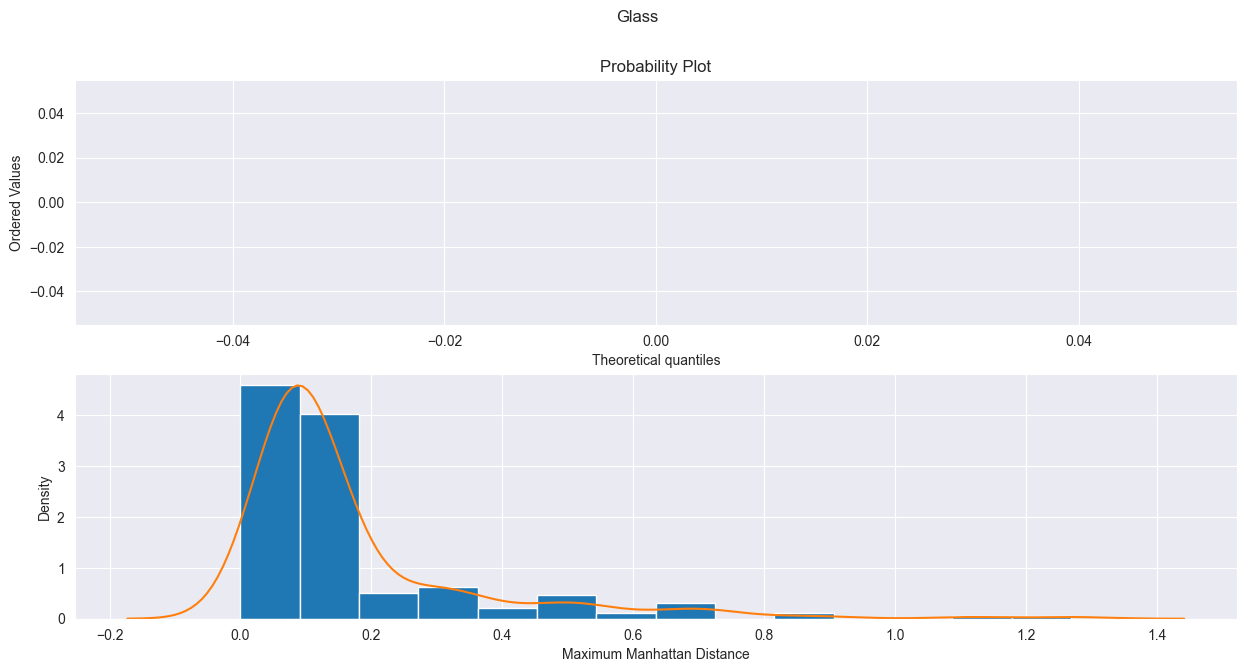

In [17]:
X, y = setupDf("real/Glass_withoutdupl_norm.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,2,"Glass")

0.7583237657864523 39 [0.5998851894374283, 0.5924225028702641, 0.6262916188289323, 0.6113662456946038, 0.6331802525832376, 0.661308840413318, 0.6653272101033295, 0.6808266360505166, 0.6739380022962111, 0.6710677382319172, 0.6905855338691159, 0.6928817451205511, 0.6986222732491388, 0.700918484500574, 0.7175660160734787, 0.7152698048220436, 0.7152698048220436, 0.7233065442020665, 0.7181400688863374, 0.7336394948335248, 0.7359357060849597, 0.738231917336395, 0.7330654420206659, 0.7336394948335246, 0.7376578645235361, 0.7359357060849598, 0.7347876004592423, 0.7451205510907003, 0.7462686567164178, 0.7462686567164178, 0.7508610792192882, 0.7485648679678529, 0.7491389207807118, 0.7433983926521239, 0.7439724454649826, 0.7520091848450057, 0.7548794489092996, 0.7583237657864523, 0.7508610792192881, 0.7474167623421355, 0.756601607347876, 0.750861079219288, 0.7474167623421354, 0.7462686567164178, 0.7554535017221584, 0.7571756601607348, 0.7514351320321467, 0.754305396096441, 0.7525832376578645, 0.7

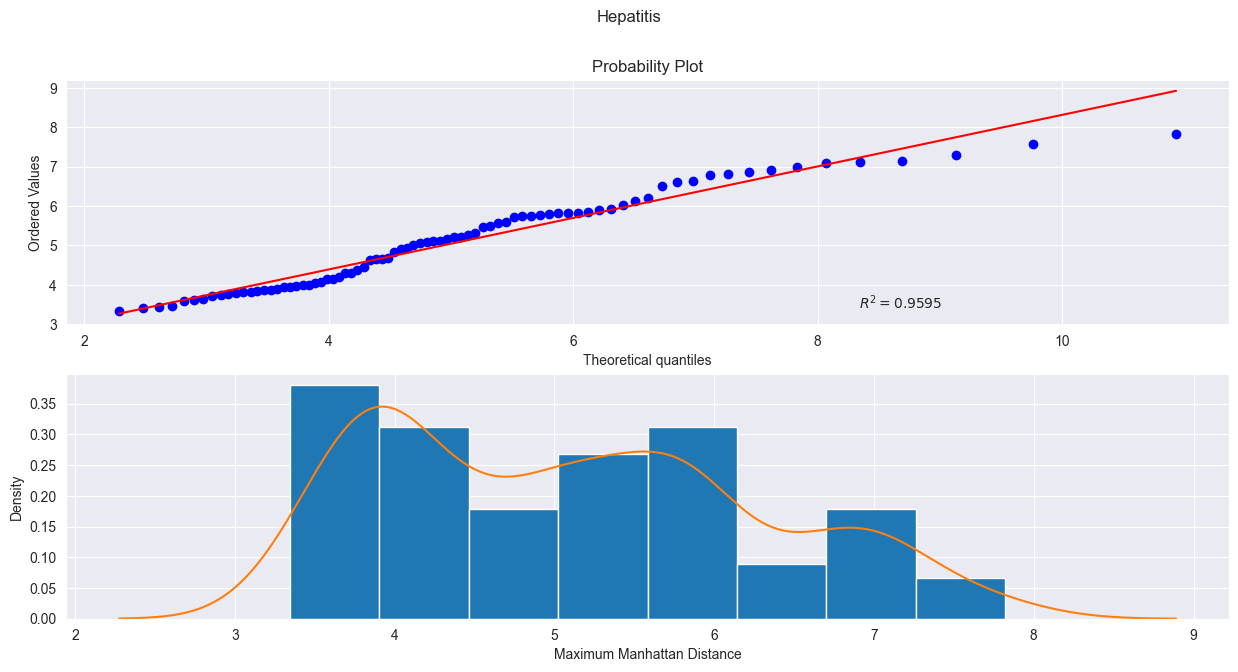

In [18]:
X, y = setupDf("real/Hepatitis_withoutdupl_norm_16.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,26,"Hepatitis")

0.7324962686567164 68 [0.6758805970149254, 0.6856044776119402, 0.6987649253731345, 0.7017313432835821, 0.7085559701492538, 0.7116268656716417, 0.7117089552238806, 0.7147014925373135, 0.7158283582089552, 0.7169328358208956, 0.7149291044776119, 0.7169514925373136, 0.7175820895522388, 0.7191268656716417, 0.7183022388059701, 0.7188320895522388, 0.7199664179104478, 0.7197910447761195, 0.7211977611940299, 0.7208768656716418, 0.7203843283582089, 0.7222313432835821, 0.7223059701492537, 0.7229738805970151, 0.7226231343283582, 0.7236716417910447, 0.7223768656716417, 0.722615671641791, 0.7229850746268657, 0.7221492537313432, 0.7231567164179105, 0.7242089552238806, 0.7236529850746267, 0.7227201492537313, 0.7220447761194029, 0.722865671641791, 0.724097014925373, 0.7235335820895522, 0.7238992537313433, 0.7249291044776118, 0.7262462686567165, 0.7258320895522388, 0.7265746268656716, 0.7272238805970149, 0.7269253731343284, 0.7268805970149255, 0.7269179104477612, 0.7270746268656716, 0.7284402985074626, 

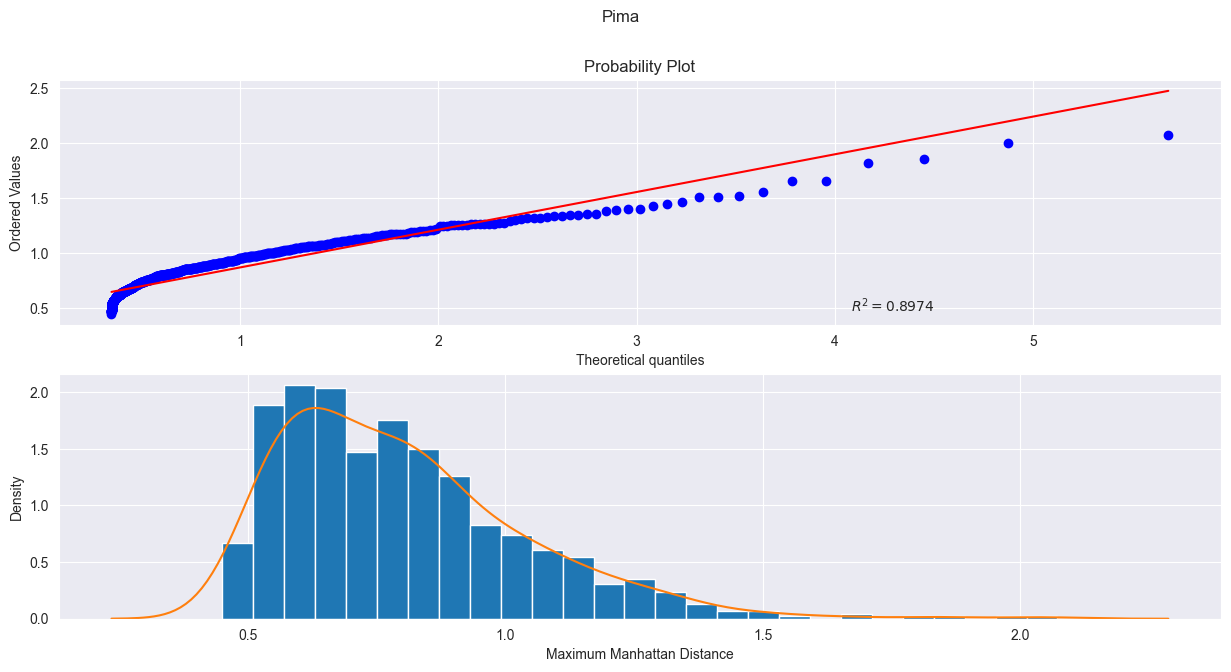

In [19]:
X, y = setupDf("real/Pima_withoutdupl_norm_35.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,69,"Pima")

0.9905615353371242 17 [0.9289652721364743, 0.9739236393176278, 0.9828696181965881, 0.9847380178716489, 0.9851340373679935, 0.9875634646628756, 0.9896628757108042, 0.9900411251015435, 0.9893963241267262, 0.9896197197400489, 0.9887083671811535, 0.9886220552396425, 0.9899421202274573, 0.9901350528025996, 0.9898202680747362, 0.9905615353371242, 0.9903736799350121, 0.9900792038992691, 0.9901452071486597, 0.9899319658813973, 0.9897669577579203, 0.9895689480097482, 0.9891729285134038, 0.9889317627944761, 0.9883580422420796, 0.9878680950446793, 0.9881371852152723, 0.9876624695369618, 0.987327376116978, 0.9868069658813973, 0.987492384240455, 0.9873578391551584, 0.9871522136474411, 0.9868171202274574, 0.986504874086109, 0.9865023354995939, 0.9861012388302193, 0.9846923233143784, 0.9850426482534526, 0.9840348294069863, 0.9846669374492282, 0.9833189480097482, 0.9840729082047116, 0.9842506092607637, 0.9832174045491473, 0.9831463241267263, 0.9830498578391551, 0.9830244719740049, 0.9827401502843217, 

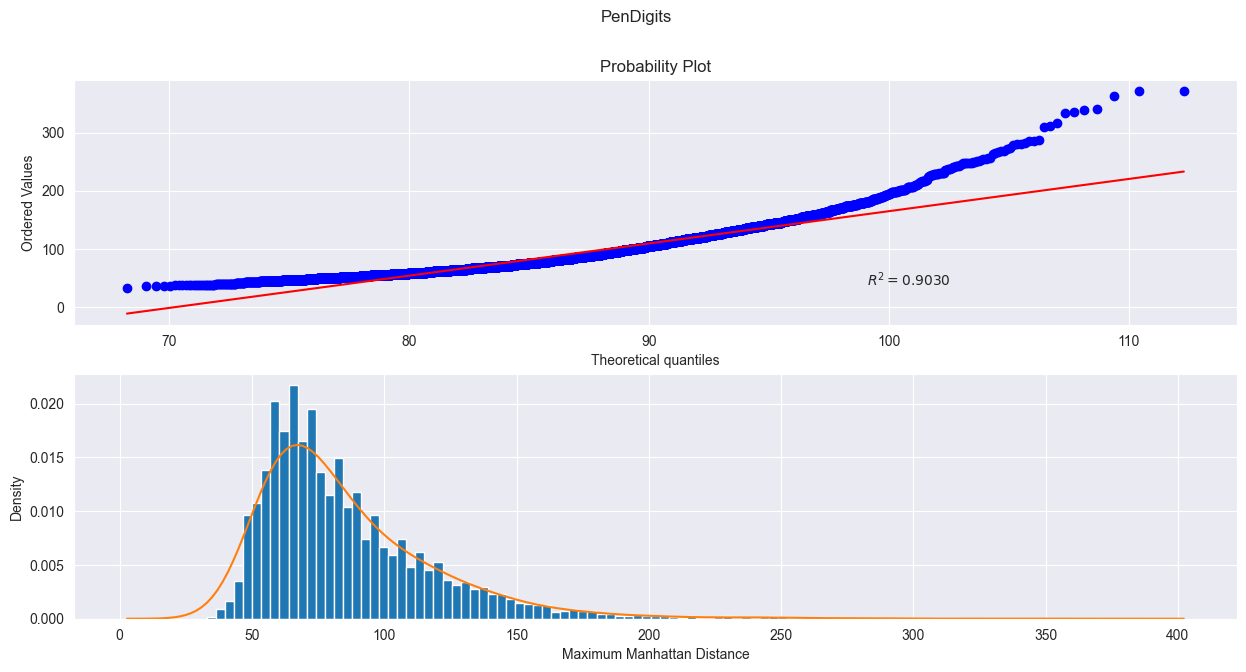

In [20]:
X, y = setupDf("real/PenDigits_withoutdupl_norm_v10.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,12,"PenDigits")

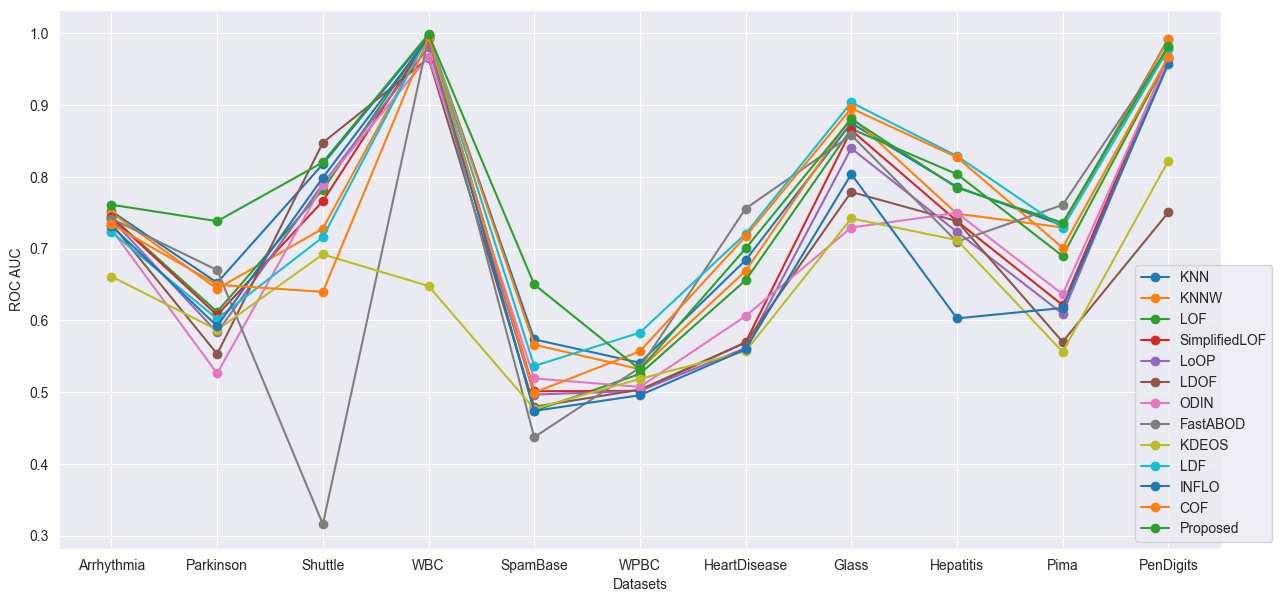

In [21]:
valuesperSet = [[0.752,0.75008,0.74421,0.74339,0.74111,0.73452,0.72669,0.74176,0.66101,0.72286,0.73154,0.73385,0.761081489734203],
[0.65235,0.64399,0.61196,0.60728,0.58312,0.55315,0.52608,0.66993,0.58673,0.60218,0.59198,0.64966,0.738166099773242],
[0.81762,0.72785,0.78208,0.76608,0.78992,0.84754,0.789,0.316,0.69192,0.71585,0.79885,0.63969,0.820153846153846],
[0.99718,0.99718,0.99671,0.9939,0.98028,0.96526,0.96737,0.99484,0.64789,0.99718,0.9939,0.99437,0.998591549295774],
[0.57347,0.56618,0.47384,0.50119,0.49658,0.4796,0.5191,0.43721,0.47667,0.53641,0.47381,0.49945,0.650009471053444],
[0.5409,0.53191,0.52543,0.50183,0.50183,0.50345,0.50726,0.53417,0.51853,0.58292,0.4957,0.55686,0.531562632098069],
[0.68383,0.66883,0.65583,0.56933,0.56139,0.56906,0.60592,0.75567,0.55694,0.72056,0.55967,0.71683,0.700166666666666],
[0.8748,0.8832,0.86667,0.86504,0.83957,0.77886,0.72927,0.85799,0.74201,0.90352,0.80379,0.89539,0.880487804878048],
[0.78588,0.74856,0.80367,0.73823,0.72331,0.73823,0.74971,0.70953,0.71183,0.82893,0.60276,0.82721,0.784730195177956],
[0.73224,0.72944,0.68955,0.62131,0.60922,0.57004,0.63637,0.76081,0.55621,0.72888,0.61728,0.70121,0.735914179104477],
[0.99212,0.9916,0.96581,0.9668,0.96231,0.75034,0.96432,0.97979,0.82214,0.97791,0.95712,0.96695,0.982605605199025],
]
datasets = ['Arrhythmia','Parkinson','Shuttle','WBC','SpamBase','WPBC','HeartDisease','Glass','Hepatitis','Pima','PenDigits']

algo = ['KNN','KNNW','LOF','SimplifiedLOF','LoOP','LDOF','ODIN','FastABOD','KDEOS','LDF','INFLO','COF','Proposed']

plt.plot(datasets,valuesperSet,marker='o')
plt.ylabel("ROC AUC")
plt.xlabel("Datasets")
plt.legend(algo,loc=4,bbox_to_anchor=(1.05,0))
plt.show()